# AUTHOR: RASHPINDER KAUR CHAHAL
# SUBMISSION DATE: 21-01-2025

In [45]:
import pandas as pd
import numpy as np
pd.__version__

'2.2.2'

In [ ]:
#installed the version which supports xls file 
pip install xlrd 

In [50]:
pd.options.display.float_format = "{:.5f}".format
pd.set_option("display.max_rows",250)

In [18]:
# skiprows to skip 17 rows 
# skipfooter to skip the extra information at the end of the data 
# usecols to specify to get the data from col C to col F

energy=pd.read_excel("EnergyIndicators.xls",skiprows=17,skipfooter=38,usecols="C:F")
energy.columns = ['Country', 'Energy Supply', 'Energy Supply per Capita', '% Renewable']

In [20]:
# b)
# Converting missing values to NA
#energy['Energy Supply']=energy['Energy Supply'].replace('...',np.NAN)
#errors='coerce' tells pandas to convert any non-numeric values (like strings or missing values) into NaN (Not a Number) instead of raising an error.
energy['Energy Supply'] = pd.to_numeric(energy['Energy Supply'], errors='coerce')

# Converting 'Energy Supply' from petajoules to gigajoules (1 PJ = 1,000,000 GJ)
energy['Energy Supply']=energy['Energy Supply']*1000000


In [21]:
# isdigits() method will return us the values which contain digits in the name of the countries

def countries_with_numbers(country_list):
    countries_with_numbers = [country for country in country_list if any(char.isdigit() for char in country)]
    return countries_with_numbers

countries = energy['Country']
print(countries_with_numbers(countries))

remove_num_country={'Australia1': 'Australia', 'China2':'China',
                    'China, Hong Kong Special Administrative Region3':'China, Hong Kong Special Administrative Region', 
                    'China, Macao Special Administrative Region4':'China, Macao Special Administrative Region',
                    'Denmark5':'Denmark', 'France6':'France', 
                    'Greenland7':'Greenland', 'Indonesia8':'Indonesia', 
                    'Italy9':'Italy', 'Japan10':'Japan', 
                    'Kuwait11':'Kuwait', 'Netherlands12':'Netherlands', 
                    'Portugal13':'Portugal', 'Saudi Arabia14':'Saudi Arabia', 'Serbia15':'Serbia',
                    'Spain16':'Spain', 'Switzerland17':'Switzerland','Ukraine18':'Ukraine',
                    'United Kingdom of Great Britain and Northern Ireland19':'United Kingdom of Great Britain and Northern Ireland', 
                    'United States of America20':'United States of America'
    
}
energy['Country']=energy['Country'].replace(remove_num_country)
print(energy['Country'])

['Australia1', 'China2', 'China, Hong Kong Special Administrative Region3', 'China, Macao Special Administrative Region4', 'Denmark5', 'France6', 'Greenland7', 'Indonesia8', 'Italy9', 'Japan10', 'Kuwait11', 'Netherlands12', 'Portugal13', 'Saudi Arabia14', 'Serbia15', 'Spain16', 'Switzerland17', 'Ukraine18', 'United Kingdom of Great Britain and Northern Ireland19', 'United States of America20']
0                                            Afghanistan
1                                                Albania
2                                                Algeria
3                                         American Samoa
4                                                Andorra
5                                                 Angola
6                                               Anguilla
7                                    Antigua and Barbuda
8                                              Argentina
9                                                Armenia
10                               

In [22]:
country_rename = {
    "Republic of Korea": "South Korea",
    "United States of America": "United States",
    "United Kingdom of Great Britain and Northern Ireland": "United Kingdom",
    "China, Hong Kong Special Administrative Region": "Hong Kong"
}

# Replace the names as per the dictionary
energy['Country'] = energy['Country'].replace(country_rename)

# Remove parentheses and their contents using string methods, r(regular expression) 
energy['Country'] = energy['Country'].str.replace(r'\(.*\)','',regex=True)

# remove the trailing space at the end of name of country use str.rstrip() method
energy['Country'] = energy['Country'].str.rstrip()
print(energy['Country'])


0                                     Afghanistan
1                                         Albania
2                                         Algeria
3                                  American Samoa
4                                         Andorra
5                                          Angola
6                                        Anguilla
7                             Antigua and Barbuda
8                                       Argentina
9                                         Armenia
10                                          Aruba
11                                      Australia
12                                        Austria
13                                     Azerbaijan
14                                        Bahamas
15                                        Bahrain
16                                     Bangladesh
17                                       Barbados
18                                        Belarus
19                                        Belgium


In [23]:
GDP=pd.read_csv("world_bank.csv",skiprows=4)

In [24]:
GDP.columns

Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015'],
      dtype='object')

In [25]:

GDP["Country Name"]=GDP["Country Name"].replace({"Korea, Rep.": "South Korea", "Iran, Islamic Rep." : "Iran","Hong Kong SAR, China" : "Hong Kong"})


In [26]:
ScimEn=pd.read_excel("scimagojr-3.xlsx")

In [27]:
ScimEn

,Rank,Country,Documents,Citable documents,Citations,Self-citations,Citations per document,H index
0,1,China,127050,126767,597237,411683,4.70000,138
1,2,United States,96661,94747,792274,265436,8.20000,230
2,3,Japan,30504,30287,223024,61554,7.31000,134
3,4,United Kingdom,20944,20357,206091,37874,9.84000,139
4,5,Russian Federation,18534,18301,34266,12422,1.85000,57
5,6,Canada,17899,17620,215003,40930,12.01000,149
6,7,Germany,17027,16831,140566,27426,8.26000,126
7,8,India,15005,14841,128763,37209,8.58000,115
8,9,France,13153,12973,130632,28601,9.93000,114
9,10,South Korea,11983,11923,114675,22595,9.57000,104


In [28]:
GDP=GDP.rename(columns={'Country Name':'Country'})
GDP.columns

Index(['Country', 'Country Code', 'Indicator Name', 'Indicator Code', '1960',
       '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969',
       '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978',
       '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987',
       '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996',
       '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005',
       '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014',
       '2015'],
      dtype='object')

In [29]:
energy

,Country,Energy Supply,Energy Supply per Capita,% Renewable
0,Afghanistan,321000000.00000,10,78.66928
1,Albania,102000000.00000,35,100.00000
2,Algeria,1959000000.00000,51,0.55101
3,American Samoa,NaN,...,0.64103
4,Andorra,9000000.00000,121,88.69565
5,Angola,642000000.00000,27,70.90909
6,Anguilla,2000000.00000,136,0.00000
7,Antigua and Barbuda,8000000.00000,84,0.00000
8,Argentina,3378000000.00000,79,24.06452
9,Armenia,143000000.00000,48,28.23606


In [30]:
# Step 1: Filter the GDP DataFrame to only include the years 2006-2015
GDP = GDP[['Country', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015']]

# Step 2: Filter the ScimEn DataFrame to include only the top 15 ranked countries
ScimEn = ScimEn[ScimEn['Rank'] <= 15]

# Step 3: Merge the datasets
# First, merge ScimEn with Energy on 'Country' and keep only countries that appear in both datasets
merged_data = pd.merge(ScimEn, energy, on='Country')

# Then, merge this with the GDP data, keeping only countries that appear in both ScimEn and Energy
merged_data = pd.merge(merged_data, GDP, on='Country')

# Step 4: Set the index to the 'Country' column
merged_data.set_index('Country', inplace=True)

# Step 5: Select only the required columns
columns = ['Rank', 'Documents', 'Citable documents', 'Citations', 'Self-citations', 
           'Citations per document', 'H index', 'Energy Supply', 'Energy Supply per Capita', 
           '% Renewable','2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015']

merged = merged_data[columns]



In [31]:
merged.T

Country,China,United States,Japan,United Kingdom,Russian Federation,Canada,Germany,India,France,South Korea,Italy,Spain,Iran,Australia,Brazil
Rank,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
Documents,127050,96661,30504,20944,18534,17899,17027,15005,13153,11983,10964,9428,8896,8831,8668
Citable documents,126767,94747,30287,20357,18301,17620,16831,14841,12973,11923,10794,9330,8819,8725,8596
Citations,597237,792274,223024,206091,34266,215003,140566,128763,130632,114675,111850,123336,57470,90765,60702
Self-citations,411683,265436,61554,37874,12422,40930,27426,37209,28601,22595,26661,23964,19125,15606,14396
Citations per document,4.70000,8.20000,7.31000,9.84000,1.85000,12.01000,8.26000,8.58000,9.93000,9.57000,10.20000,13.08000,6.46000,10.28000,7.00000
H index,138,230,134,139,57,149,126,115,114,104,106,115,72,107,86
Energy Supply,127191000000.00000,90838000000.00000,18984000000.00000,7920000000.00000,30709000000.00000,10431000000.00000,13261000000.00000,33195000000.00000,10597000000.00000,11007000000.00000,6530000000.00000,4923000000.00000,9172000000.00000,5386000000.00000,12149000000.00000
Energy Supply per Capita,93,286,149,124,214,296,165,26,166,221,109,106,119,231,59
% Renewable,19.75491,11.57098,10.23282,10.60047,17.28868,61.94543,17.90153,14.96908,17.02028,2.27935,33.66723,37.96859,5.70772,11.81081,69.64803


In [32]:
#Q2) [Moderate] What are the top 15 countries for average GDP over the last 10 years? 
#[NB: This function should return a Series named ‘avgGDP’ with 15 countries and their average GDP sorted in descending order.] 
def avgGDP():
    avgGDP=merged[['2006','2007','2008','2009','2010','2011','2012','2013','2014','2015']].agg('mean',axis=1)
    avgGDP.sort_values(ascending=False,inplace=True)
    return(avgGDP)

avgGDP()

Country
United States        15364344302990.00000
China                 6348608932836.09961
Japan                 5542207638235.17578
Germany               3493025339072.84766
France                2681724635761.58887
United Kingdom        2487906661418.41748
Brazil                2189794143774.90503
Italy                 2120175089933.77612
India                 1769297396603.86011
Canada                1660647466307.51196
Russian Federation    1565459478480.66089
Spain                 1418078278145.69409
Australia             1164042729991.42700
South Korea           1106714508244.85205
Iran                   444155754051.09497
dtype: float64

In [33]:
#Q3) [Moderate] By how much had the GDP changed over the 10 year span for the country with the 6th largest average GDP? 
#[NB: This function should return a single number.] 
avg_GDP=avgGDP()
country=avg_GDP.index[5]
#so the Country with sixth largest average GDP is Italy
# In order to find the GDP change over last 10 years, we should calculate the difference between first and last year GDP
def GDP_change(country):
    return merged.loc[country,'2006']-merged.loc[country,'2015']
    

GDP_change=GDP_change(country)
print("The GDP changed over the 10 year span for the country with the 6th largest average GDP is:",GDP_change)

The GDP changed over the 10 year span for the country with the 6th largest average GDP is: -246702696075.3999


In [34]:
#Q4) [Trivial] What is the mean energy supply per capita? 
#[NB: This function should return a single number.] [1 Mark]
def mean_ESPC():
    return merged['Energy Supply per Capita'].agg('mean')
    
print("The mean energy supply per capita is:",mean_ESPC())

The mean energy supply per capita is: 157.6


In [35]:
#Q5) [Trivial] Which country has the maximum % Renewable and what is the percentage? 
#[NB: This function should return a tuple with the name of the country and the percentage.] [1 Mark]

def Max_per_renewable():
    Country_name=merged['% Renewable'].idxmax()
    Percentage=merged['% Renewable'].agg('max')
    return (Country_name,Percentage)


Max_per_renewable()

('Brazil', 69.64803)

In [36]:
#Q6) [Trivial] Create a new column that is the ratio of Self-Citations to Total Citations.
#What is the maximum value for this new column, and which country has the highest ratio? 
#[NB: This function should return a tuple with the name of the country and the ratio.] [1 Mark]

merged['Ratio_self_to_total_citations']=merged.agg(lambda x: x['Self-citations'] / x['Citations'], axis=1)

def country_max_citation_ratio():
    max_value=merged['Ratio_self_to_total_citations'].agg('max')
    country=merged['Ratio_self_to_total_citations'].idxmax()
    return (country,max_value)
    
country_max_citation_ratio()

('China', 0.6893126179389422)

In [49]:
#Q7) [Moderate] Create a column that estimates the population using Energy Supply and Energy Supply per capita. 
#What is the third most populous country according to this estimate? [NB: This function should return a single string value.] [1 Mark]
merged['Population']=merged.agg(lambda x: x['Energy Supply'] / x['Energy Supply per Capita'], axis=1)

def Countries_sorted():
    Countries_sorted=merged['Population'].sort_values(ascending=False)
    return Countries_sorted.index[2]

Countries_sorted()

'United States'

The correlation between the number of citable documents per capita and the energy supply per capita is: 0.7940010435442946


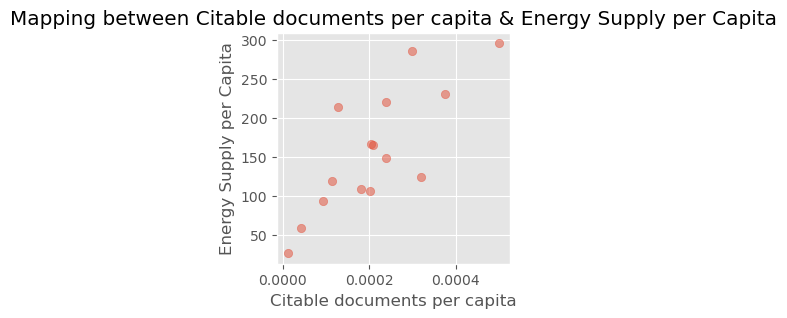

In [39]:
#Q8) [Moderate] Create a column that estimates the number of citable documents per person. 
#What is the correlation between the number of citable documents per capita and the energy supply per capita?
#Use the “.corr()” method, (Pearson's correlation). 
#[NB: This function should return a single number.] 
#Plot to visualize the relationship between Energy Supply per Capita vs. Citable docs per Capita. [1 Mark]

merged['Citable documents per capita']=merged['Citable documents'] / merged['Population']

def corr_cit_docs_pop():
     return merged['Citable documents per capita'].corr(merged['Energy Supply per Capita'])


print("The correlation between the number of citable documents per capita and the energy supply per capita is:",corr_cit_docs_pop())

#Plotting Scatter Plot for correlation

import matplotlib.pyplot as plt
# Use the 'ggplot' style
plt.style.use('ggplot')

fig, ax = plt.subplots(1,1, figsize=(3,3))

ax.scatter(merged['Citable documents per capita'], merged['Energy Supply per Capita'], alpha=0.5) 
ax.set_xlabel("Citable documents per capita")
ax.set_ylabel("Energy Supply per Capita")
ax.set_title("Mapping between Citable documents per capita & Energy Supply per Capita")

plt.show()

In [30]:
merged.T

Country,China,Japan,Russian Federation,Canada,Germany,India,France,Italy,Spain,Australia,Brazil
Rank,1,3,5,6,7,8,9,11,12,14,15
Documents,127050,30504,18534,17899,17027,15005,13153,10964,9428,8831,8668
Citable documents,126767,30287,18301,17620,16831,14841,12973,10794,9330,8725,8596
Citations,597237,223024,34266,215003,140566,128763,130632,111850,123336,90765,60702
Self-citations,411683,61554,12422,40930,27426,37209,28601,26661,23964,15606,14396
Citations per document,4.70000,7.31000,1.85000,12.01000,8.26000,8.58000,9.93000,10.20000,13.08000,10.28000,7.00000
H index,138,134,57,149,126,115,114,106,115,107,86
Energy Supply,127191000000.00000,18984000000.00000,30709000000.00000,10431000000.00000,13261000000.00000,33195000000.00000,10597000000.00000,6530000000.00000,4923000000.00000,5386000000.00000,12149000000.00000
Energy Supply per Capita,93,149,214,296,165,26,166,109,106,231,59
% Renewable,19.75491,10.23282,17.28868,61.94543,17.90153,14.96908,17.02028,33.66723,37.96859,11.81081,69.64803


In [48]:
#Q9) [Moderate] Create a new column with a 1 if the country's % Renewable value is at or above the median for all countries in the top 15, 
#               and a 0 if the country's % Renewable value is below the median. 
#[NB: This function should return a series named “HighRenew” whose index is the country name sorted in ascending order of rank.] [1 Mark]

def HighRenew():
    median_renewable = merged['% Renewable'].median()
    merged['HighRenew'] = (merged['% Renewable'] >= median_renewable).astype(int)
    merged_sorted = merged.sort_values(by='Rank')
    return merged_sorted['HighRenew']

HighRenew()

Country
China                 1
United States         0
Japan                 0
United Kingdom        0
Russian Federation    1
Canada                1
Germany               1
India                 0
France                1
South Korea           0
Italy                 1
Spain                 1
Iran                  0
Australia             0
Brazil                1
Name: HighRenew, dtype: int32

In [42]:
ContinentDict = {'China':'Asia', 'United States':'North America', 'Japan':'Asia', 'United Kingdom':'Europe', 
                 'Russian Federation':'Europe', 'Canada':'North America', 'Germany':'Europe', 'India':'Asia',
                 'France':'Europe', 'South Korea':'Asia', 'Italy':'Europe', 'Spain':'Europe', 'Iran':'Asia',
                 'Australia':'Australia', 'Brazil':'South America'}
#We use the ContinentDict to map the Country names in the merged DataFrame to their respective continents. The map function is used for this.

def map_continent_country():
    merged['Continent'] = merged.index.map(ContinentDict)
    return merged.groupby('Continent')['Population'].agg(['size', 'sum', 'mean', 'std'])

map_continent_country()

,size,sum,mean,std
Continent,,,,
Asia,5,2898666386.61060,579733277.32212,679097888.36610
Australia,1,23316017.31602,23316017.31602,NaN
Europe,6,457929667.21637,76321611.20273,34647667.06562
North America,2,352855249.48025,176427624.74012,199669644.85667
South America,1,205915254.23729,205915254.23729,NaN


In [43]:
#Q11) [Advanced] Cut % Renewable into 5 bins. Group Top15 by the Continent, as well as these new % Renewable bins. 
#How many countries are in each of these groups? 
#[NB: This function should return a Series with a MultiIndex of ‘Continent’, then the bins for ‘% Renewable’.
#Do not include groups with no countries.] [1 Mark]

# to create 5 bins for the % Renewable values using pd.cut.
# Group by both continent and bin using groupby.
# Count the countries in each group using size() and filter out any groups with zero countries.

def cont_bin_percent_renewable():
    merged['Renewable Bin'] = pd.cut(merged['% Renewable'], bins=5)
    grouped = merged.groupby(['Continent', 'Renewable Bin']).size()
    grouped = grouped[grouped > 0]
    return grouped

cont_bin_percent_renewable()

C:\Users\hp\AppData\Local\Temp\ipykernel_3276\2030121620.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = merged.groupby(['Continent', 'Renewable Bin']).size()


Continent      Renewable Bin   
Asia           (2.212, 15.753]     4
               (15.753, 29.227]    1
Australia      (2.212, 15.753]     1
Europe         (2.212, 15.753]     1
               (15.753, 29.227]    3
               (29.227, 42.701]    2
North America  (2.212, 15.753]     1
               (56.174, 69.648]    1
South America  (56.174, 69.648]    1
dtype: int64

In [44]:
#Q12) [Moderate] Convert the Population Estimate series to a string with thousands separator (using commas). Do not round the results. [1 Mark]
#e.g. 317615384.61538464 -> 317,615,384.61538464
#[NB: This function should return a Series PopEst whose index is the country name and whose values are the population estimate string.]

# Formatting the 'Population' column to add commas as thousands separators

def PopEst():
    return merged['Population'].apply(lambda x: f'{x:,.8f}')

PopEst()

Country
China                 1,367,645,161.29032254
United States           317,615,384.61538464
Japan                   127,409,395.97315437
United Kingdom           63,870,967.74193548
Russian Federation      143,500,000.00000000
Canada                   35,239,864.86486486
Germany                  80,369,696.96969697
India                 1,276,730,769.23076916
France                   63,837,349.39759036
South Korea              49,805,429.86425339
Italy                    59,908,256.88073394
Spain                    46,443,396.22641510
Iran                     77,075,630.25210084
Australia                23,316,017.31601731
Brazil                  205,915,254.23728815
Name: Population, dtype: object